# Evaluación de Modelos - Fraude 🕵️‍♂️💳

Este notebook documenta el proceso de evaluación de un modelo de detección de fraude financiero. Se presentan los resultados de las métricas de desempeño, la matriz de confusión, la curva ROC y la importancia de las variables, utilizando datos reales de transacciones.

> **Objetivo:** Analizar el rendimiento del modelo y comprender qué variables son más relevantes para identificar patrones de fraude, con el fin de construir soluciones robustas que ayuden a proteger a los usuarios y prevenir pérdidas económicas.

In [1]:
#librerias  
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, average_precision_score
)

**Cargar datos y modelo entrenado** 🗂️🤖

En esta sección se cargan los datos procesados y el modelo final entrenado para la detección de fraude. Estos elementos son fundamentales para realizar las predicciones y evaluar el desempeño del sistema en transacciones reales.

In [17]:
# Datos procesados
X_test = np.load('../data/processed/X_test.npy')
y_test = np.load('../data/processed/y_test.npy')

# Cargar nombres de columnas 
column_names = pd.read_csv('../data/raw/creditcard.csv', nrows=1).columns.tolist()
X_test = pd.DataFrame(X_test, columns=column_names[:-1])  # Excluye la columna 'Class' si no está en X_test

# modelo final entrenado
model = joblib.load('../models/lgbm_fraud_model.pkl')

# Predicciones
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

📝 **Reporte de Clasificación**

En esta sección se presentan los resultados del modelo de detección de fraude, incluyendo las métricas clave de desempeño. El reporte permite analizar la precisión, recall, F1-score y soporte para cada clase, facilitando la interpretación del rendimiento y la identificación de posibles áreas de mejora en la detección de transacciones fraudulentas. 📊🔍

In [20]:
print('Classification Report:')
print(classification_report(y_test, y_pred, digits=4))



Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9997    0.9997     85295
           1     0.8333    0.7770    0.8042       148

    accuracy                         0.9993     85443
   macro avg     0.9165    0.8884    0.9019     85443
weighted avg     0.9993    0.9993    0.9993     85443



🔢 **Matriz de Confusión**

La matriz de confusión permite visualizar el desempeño del modelo en la clasificación de transacciones legítimas y fraudulentas. Es una herramienta clave para identificar aciertos y errores, facilitando el análisis de falsos positivos y falsos negativos en la detección de fraude. 🕵️‍♀️💳

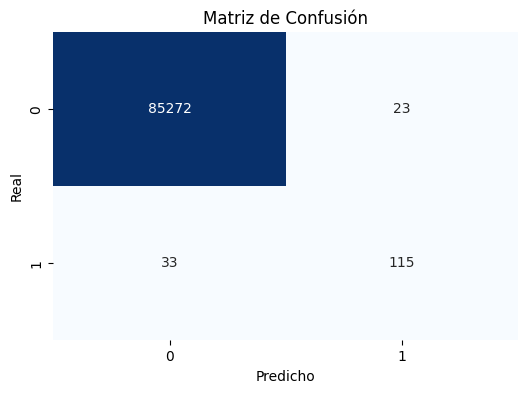

In [21]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

🚦 **Curva ROC**

La curva ROC (Receiver Operating Characteristic) es una herramienta fundamental para evaluar el desempeño de modelos de clasificación, especialmente en problemas de detección de fraude. Permite visualizar la capacidad del modelo para distinguir entre transacciones legítimas y fraudulentas, mostrando la relación entre la tasa de verdaderos positivos y la tasa de falsos positivos. Un área bajo la curva (AUC) alta indica un modelo robusto y efectivo en la identificación de fraudes. 📈🔍

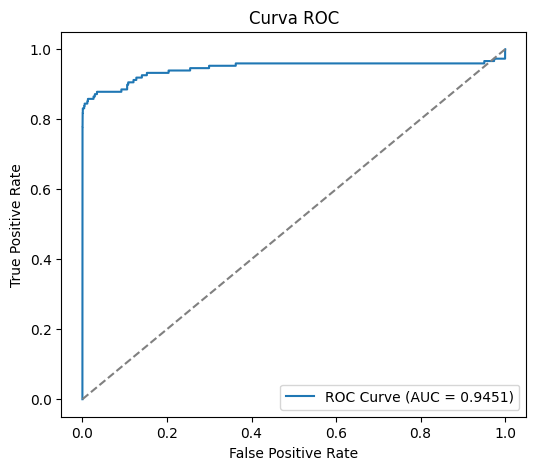

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()


🔍 **Importancia de Features**

En esta sección se analiza la importancia de las variables utilizadas por el modelo para detectar fraude. Visualizar las características más relevantes permite comprender qué factores influyen en la predicción y ayuda a optimizar futuras estrategias de prevención. Las variables con mayor importancia aportan información clave para identificar patrones sospechosos y fortalecer la seguridad financiera. 🚀💡

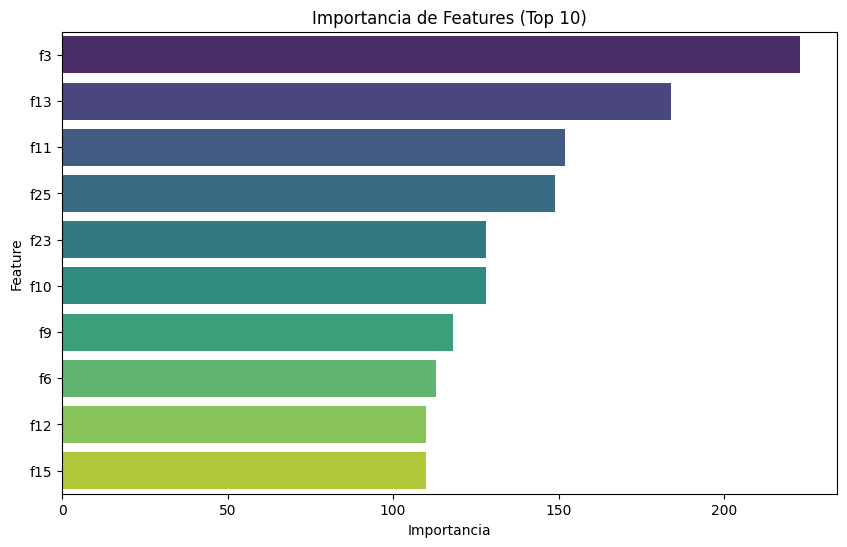

In [32]:
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    features = [f"f{i}" for i in range(len(importances))]

    feat_df = pd.DataFrame({'Feature': features, 'Importancia': importances})
    feat_df = feat_df.sort_values(by='Importancia', ascending=False)

    plt.figure(figsize=(10,6))
    sns.barplot(feat_df.head(10), x='Importancia', y='Feature', hue='Feature', palette='viridis', legend=False)
    plt.title('Importancia de Features (Top 10)')
    plt.show()